# 6주차 - 분위수별 SHAP + 오류 분석 4축 + DM test + 위기구간

> 계획서 v5.1 §6 + §7 + §9 W6 직격.

## 본 노트북의 목표

| 작업 | 계획서 근거 | 산출물 |
|------|------------|--------|
| §1. 분위수별 SHAP DeepExplainer (q05/q50/q95 각각) | §6.1 + §6.2 | `reports/lstm_a0_shap_w6.npz` |
| §2. 시차 효과 정량화 | §6.3 | `w6_02_shap_time_heatmap.png` |
| §3. 위기구간 라벨 (train-only threshold, V3 LOG #43) | §4.4 | `reports/crisis_labels_w6.csv` |
| §4. 오류 분석 4축 | §6.4 | `reports/error_analysis_w6.csv` |
| §5. DM test (HAC+HLN+Bonferroni) | §7 | `reports/dm_test_w6.csv` |
| §6. 채널 부합 (V6 LOG #43 영역 분리) | §6.5 | `reports/channel_validation_w6.csv` |
| §7. 요약 | §9 | `reports/summary_w6.md` |

---

## 0. 환경 + 데이터/모델 로드

In [1]:
import importlib.util, subprocess, sys
for _name in ['torch','shap','sklearn','matplotlib','yaml','statsmodels']:
    if importlib.util.find_spec(_name) is None:
        pip_name = {'sklearn':'scikit-learn','yaml':'pyyaml'}.get(_name, _name)
        subprocess.check_call([sys.executable,'-m','pip','install','-q',pip_name])
import pickle, json
import yaml, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from sklearn.preprocessing import RobustScaler
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT/'data'; MODELS_DIR = PROJECT_ROOT/'models'
REPORT_DIR = PROJECT_ROOT/'reports'; FIG_DIR = REPORT_DIR/'figures'
with open(PROJECT_ROOT/'configs/config.yaml', encoding='utf-8') as f:
    CONFIG = yaml.safe_load(f)
LOOKBACK = CONFIG['features']['lookback_window']
QUANTILES = [0.05, 0.5, 0.95]
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print('torch', torch.__version__, 'device:', DEVICE)

torch 2.11.0+cpu device: cpu


In [2]:
fv = pd.read_csv(DATA_DIR/'processed/features_v1_candidate.csv', index_col='date', parse_dates=['date']).sort_index()
fwl = pd.read_csv(DATA_DIR/'processed/features_with_lags_v1.csv', index_col='date', parse_dates=['date']).sort_index()
with open(MODELS_DIR/'scaler_robust_train.pkl','rb') as f:
    SPLIT = pickle.load(f)['split']
FROZEN = ['kr_treasury_3y','kr_base_rate','us_treasury_10y','us_fed_funds','us_breakeven_10y','vix','sp500','dxy']
def slice_period(df, p):
    s,e = SPLIT[p]; return df.loc[s:e]
df_diff = fv[FROZEN].diff().shift(1)
df_diff.columns = [f'd_{c}' for c in FROZEN]
X_train_raw = slice_period(df_diff,'train').dropna()
X_val_raw = slice_period(df_diff,'val').dropna()
X_test_raw = slice_period(df_diff,'test').dropna()
scaler = RobustScaler().fit(X_train_raw)
def tr(d): return pd.DataFrame(scaler.transform(d), index=d.index, columns=d.columns)
X_train, X_val, X_test = tr(X_train_raw), tr(X_val_raw), tr(X_test_raw)
y_train = slice_period(fwl,'train')['delta_y_bp']
y_val = slice_period(fwl,'val')['delta_y_bp']
y_test = slice_period(fwl,'test')['delta_y_bp']
def make_sequences(X_df, y_ser, lookback):
    idx = X_df.index.intersection(y_ser.index)
    X = X_df.loc[idx].to_numpy(dtype=np.float32)
    y = y_ser.loc[idx].to_numpy(dtype=np.float32)
    seqs, tgts, dates = [], [], []
    arr = idx.to_numpy()
    for t in range(lookback - 1, len(X)):
        if np.isnan(y[t]) or np.isnan(X[t-lookback+1:t+1]).any(): continue
        seqs.append(X[t-lookback+1:t+1]); tgts.append(y[t]); dates.append(arr[t])
    return np.stack(seqs), np.array(tgts, dtype=np.float32), np.array(dates)
Xs_train, ys_train, dt_train = make_sequences(X_train, y_train, LOOKBACK)
Xs_val, ys_val, dt_val = make_sequences(X_val, y_val, LOOKBACK)
Xs_test, ys_test, dt_test = make_sequences(X_test, y_test, LOOKBACK)
print('seq:', Xs_train.shape, Xs_val.shape, Xs_test.shape)

seq: (2524, 30, 8) (205, 30, 8) (672, 30, 8)


In [3]:
ckpt = torch.load(MODELS_DIR/'lstm_a0_final_w5.pt', map_location=DEVICE, weights_only=False)
cfg = ckpt['config']
print('A0 final config:', cfg['hidden'], cfg['lr'], 'seed', cfg['seed'])
class QuantileLSTM(nn.Module):
    def __init__(self, input_dim, hidden, layers, dropout, n_q):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, num_layers=layers, batch_first=True, dropout=dropout if layers>1 else 0.0)
        self.head = nn.Linear(hidden, n_q)
    def forward(self, x):
        out,_ = self.lstm(x); return self.head(out[:,-1,:])
model = QuantileLSTM(len(FROZEN), cfg['hidden'], cfg['layers'], cfg['dropout'], len(QUANTILES)).to(DEVICE)
model.load_state_dict(ckpt['state_dict']); model.eval()
print('A0 loaded.')

A0 final config: 128 0.0005 seed 123
A0 loaded.


In [4]:
@torch.no_grad()
def predict_sorted(m, Xs):
    m.eval()
    p = m(torch.from_numpy(Xs).float().to(DEVICE)).cpu().numpy()
    arr = np.sort(p, axis=1)
    return {q: arr[:,i] for i,q in enumerate(QUANTILES)}
preds_val = predict_sorted(model, Xs_val)
preds_test = predict_sorted(model, Xs_test)
rows_a0 = []
for sp_name, dates_arr, ys, ps in [('val', dt_val, ys_val, preds_val), ('test', dt_test, ys_test, preds_test)]:
    for date, y, p05, p50, p95 in zip(dates_arr, ys, ps[0.05], ps[0.5], ps[0.95]):
        rows_a0.append({'date': pd.Timestamp(date), 'split': sp_name, 'y_true_bp': float(y),
            'q05': float(p05), 'q50': float(p50), 'q95': float(p95),
            'pinball_q05': max(0.05*(y-p05), -0.95*(y-p05)),
            'pinball_q50': max(0.5*(y-p50), -0.5*(y-p50)),
            'pinball_q95': max(0.95*(y-p95), -0.05*(y-p95))})
a0_pred_df = pd.DataFrame(rows_a0)
a0_pred_df.to_csv(DATA_DIR/'processed/lstm_a0_predictions_w6.csv', index=False)
print('saved lstm_a0_predictions_w6.csv', len(a0_pred_df))

saved lstm_a0_predictions_w6.csv 877


---

## 1. 분위수별 SHAP DeepExplainer

In [5]:
import shap
rng = np.random.default_rng(SEED)
bg_idx = rng.choice(len(Xs_train), size=min(200, len(Xs_train)), replace=False)
eval_idx = rng.choice(len(Xs_test), size=min(150, len(Xs_test)), replace=False)
Xs_bg = Xs_train[bg_idx]; Xs_eval = Xs_test[eval_idx]
ys_eval = ys_test[eval_idx]; dt_eval = dt_test[eval_idx]
print('bg', Xs_bg.shape, 'eval', Xs_eval.shape)
class QuantileWrap(nn.Module):
    def __init__(self, base, q_idx):
        super().__init__(); self.base = base; self.q_idx = q_idx
    def forward(self, x): return self.base(x)[:, self.q_idx:self.q_idx+1]
shap_by_q = {}
for qi, q in enumerate(QUANTILES):
    wrap = QuantileWrap(model, qi).to(DEVICE).eval()
    bg_t = torch.from_numpy(Xs_bg).float().to(DEVICE)
    eval_t = torch.from_numpy(Xs_eval).float().to(DEVICE)
    explainer = shap.DeepExplainer(wrap, bg_t)
    sv = explainer.shap_values(eval_t, check_additivity=False)
    if isinstance(sv, list): sv = sv[0]
    sv = np.asarray(sv)
    if sv.ndim == 4 and sv.shape[-1] == 1: sv = sv[..., 0]
    shap_by_q[q] = sv
    print('  q=', q, 'shape', sv.shape, 'mean|SHAP|', round(float(np.abs(sv).mean()),5))
np.savez(REPORT_DIR/'lstm_a0_shap_w6.npz',
         shap_q05=shap_by_q[0.05], shap_q50=shap_by_q[0.5], shap_q95=shap_by_q[0.95],
         eval_dates=dt_eval, eval_y=ys_eval, eval_X=Xs_eval, features=np.array(FROZEN))
print('saved lstm_a0_shap_w6.npz')

bg (200, 30, 8) eval (150, 30, 8)


  q= 0.05 shape (150, 30, 8) mean|SHAP| 0.02942


  q= 0.5 shape (150, 30, 8) mean|SHAP| 0.01267


  q= 0.95 shape (150, 30, 8) mean|SHAP| 0.026
saved lstm_a0_shap_w6.npz


                      q05      q50      q95  mean_3q
us_treasury_10y   0.10849  0.05467  0.10203  0.08840
kr_treasury_3y    0.04442  0.01302  0.02942  0.02895
vix               0.02996  0.01166  0.03389  0.02517
sp500             0.02546  0.01031  0.02162  0.01913
dxy               0.01941  0.00527  0.00729  0.01066
us_breakeven_10y  0.00683  0.00612  0.01282  0.00859
us_fed_funds      0.00066  0.00023  0.00071  0.00053
kr_base_rate      0.00013  0.00008  0.00022  0.00015


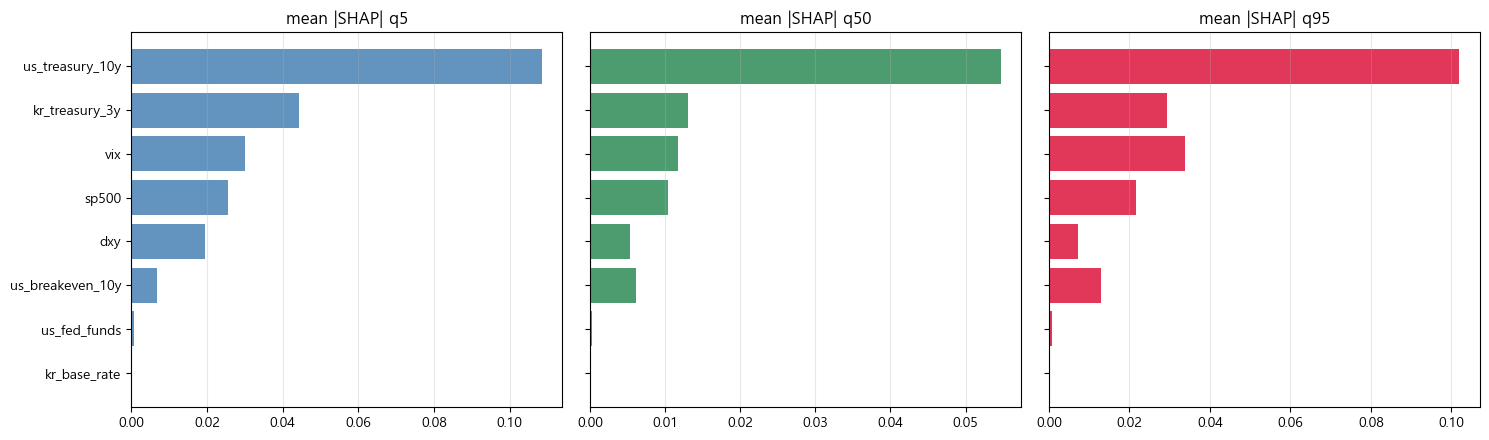

In [6]:
imp_table = pd.DataFrame({f'q{int(q*100):02d}': np.abs(shap_by_q[q]).mean(axis=(0,1)) for q in QUANTILES}, index=FROZEN)
imp_table['mean_3q'] = imp_table.mean(axis=1)
imp_table = imp_table.sort_values('mean_3q', ascending=False)
print(imp_table.round(5).to_string())
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, q, color in zip(axes, QUANTILES, ['steelblue','seagreen','crimson']):
    s = pd.Series(np.abs(shap_by_q[q]).mean(axis=(0,1)), index=FROZEN).sort_values(ascending=True)
    ax.barh(s.index, s.values, color=color, alpha=0.85)
    ax.set_title('mean |SHAP| q' + str(int(q*100)))
    ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR/'w6_01_shap_quantile.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. 시차 효과

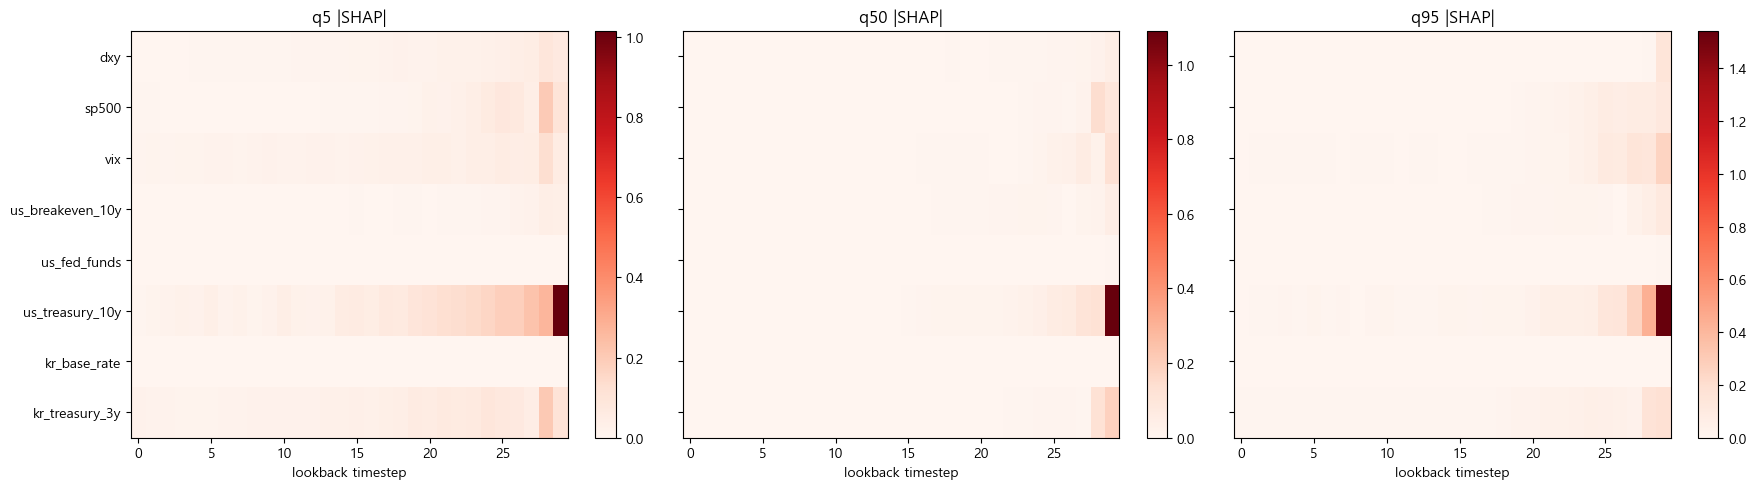

us_treasury_10y q50 peak: t-0 bdays, |SHAP|=1.09038


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, q in zip(axes, QUANTILES):
    mat = np.abs(shap_by_q[q]).mean(axis=0)
    im = ax.imshow(mat.T, aspect='auto', cmap='Reds', origin='lower')
    ax.set_yticks(np.arange(len(FROZEN))); ax.set_yticklabels(FROZEN)
    ax.set_xlabel('lookback timestep'); ax.set_title('q' + str(int(q*100)) + ' |SHAP|')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(FIG_DIR/'w6_02_shap_time_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
us10y_idx = FROZEN.index('us_treasury_10y')
us10y_time = np.abs(shap_by_q[0.5]).mean(axis=0)[:, us10y_idx]
peak_t = int(np.argmax(us10y_time))
peak_lag = LOOKBACK - 1 - peak_t
print('us_treasury_10y q50 peak: t-' + str(peak_lag) + ' bdays, |SHAP|=' + str(round(float(us10y_time[peak_t]),5)))

## 3. 위기구간 (V3 LOG #43: train-only threshold)

In [8]:
y_lvl = fv['kr_treasury_10y']
dy_full = (y_lvl.diff() * 100)
rolling_vol_20d = dy_full.rolling(20).std()
train_start, train_end = SPLIT['train']
vol_threshold = rolling_vol_20d.loc[train_start:train_end].quantile(0.8)
print('threshold (train-only):', round(float(vol_threshold), 3), 'bp')
crisis_mask_full = (rolling_vol_20d > vol_threshold)
print('full crisis ratio:', round(float(crisis_mask_full.mean())*100, 1), '%')
test_dates = pd.DatetimeIndex(dt_test)
crisis_test = crisis_mask_full.reindex(test_dates).fillna(False)
n_crisis = int(crisis_test.sum()); n_normal = int((~crisis_test).sum())
print('test crisis:', n_crisis, '/', len(test_dates), '=', round(n_crisis/len(test_dates)*100, 1), '%')
crisis_df = pd.DataFrame({'date': test_dates, 'rolling_vol_20d': rolling_vol_20d.reindex(test_dates).values, 'is_crisis': crisis_test.values})
crisis_df.to_csv(REPORT_DIR/'crisis_labels_w6.csv', index=False)
print('saved crisis_labels_w6.csv')

threshold (train-only): 4.107 bp
full crisis ratio: 29.5 %
test crisis: 299 / 672 = 44.5 %
saved crisis_labels_w6.csv


## 4. 오류 분석 4축

In [9]:
df_test = pd.DataFrame({'date': test_dates, 'y_true_bp': ys_test,
    'q05': preds_test[0.05], 'q50': preds_test[0.5], 'q95': preds_test[0.95],
    'is_crisis': crisis_test.values})
df_test['err_q50'] = df_test['y_true_bp'] - df_test['q50']
df_test['abs_err_q50'] = df_test['err_q50'].abs()
df_test['in_band'] = (df_test['y_true_bp'] >= df_test['q05']) & (df_test['y_true_bp'] <= df_test['q95'])
df_test['sign_correct'] = np.sign(df_test['q50']) == np.sign(df_test['y_true_bp'])
dir_acc = df_test['sign_correct'].mean()
print('(a) direction accuracy:', round(dir_acc*100, 1), '%')
big_miss = df_test[(df_test['y_true_bp'].abs() > 5) & (df_test['q50'].abs() < 1)]
print('(b) big miss:', len(big_miss), 'cases (', round(len(big_miss)/len(df_test)*100, 1), '%)')
miss = df_test[~df_test['in_band']]
n_miss = len(miss); n_miss_crisis = int(miss['is_crisis'].sum()); n_miss_normal = n_miss - n_miss_crisis
rate_crisis = n_miss_crisis / max(n_crisis, 1); rate_normal = n_miss_normal / max(n_normal, 1)
print('(c) Coverage:', round(df_test['in_band'].mean()*100, 1), '%')
print('    crisis miss', round(rate_crisis*100, 1), '% vs normal', round(rate_normal*100, 1), '% (ratio', round(rate_crisis/rate_normal, 2), 'x)')

(a) direction accuracy: 64.3 %
(b) big miss: 59 cases ( 8.8 %)
(c) Coverage: 90.0 %
    crisis miss 13.0 % vs normal 7.5 % (ratio 1.74 x)


In [10]:
is_crisis_eval = pd.Series(crisis_mask_full.reindex(pd.DatetimeIndex(dt_eval)).fillna(False).values)
shap_q50 = shap_by_q[0.5]
n_eval_crisis = int(is_crisis_eval.sum()); n_eval_normal = int((~is_crisis_eval).sum())
print('eval crisis', n_eval_crisis, '/ normal', n_eval_normal)
if n_eval_crisis >= 5 and n_eval_normal >= 5:
    shap_crisis = np.abs(shap_q50[is_crisis_eval.values]).mean(axis=(0,1))
    shap_normal = np.abs(shap_q50[~is_crisis_eval.values]).mean(axis=(0,1))
    diff_d = shap_crisis - shap_normal
    diff_table = pd.DataFrame({'feature': FROZEN, 'shap_crisis': shap_crisis, 'shap_normal': shap_normal,
        'diff_crisis_normal': diff_d, 'ratio_crisis_normal': shap_crisis/shap_normal}).sort_values('diff_crisis_normal', ascending=False)
    print(diff_table.round(5).to_string(index=False))
    diff_table.to_csv(REPORT_DIR/'error_analysis_w6.csv', index=False)
else:
    diff_table = pd.DataFrame()
    print('insufficient sample')

eval crisis 67 / normal 83
         feature  shap_crisis  shap_normal  diff_crisis_normal  ratio_crisis_normal
  kr_treasury_3y      0.01657      0.01016             0.00642              1.63175
 us_treasury_10y      0.05644      0.05324             0.00321              1.06024
us_breakeven_10y      0.00662      0.00572             0.00091              1.15867
    us_fed_funds      0.00028      0.00019             0.00010              1.50514
    kr_base_rate      0.00003      0.00012            -0.00008              0.28828
             dxy      0.00508      0.00542            -0.00034              0.93730
             vix      0.01013      0.01289            -0.00276              0.78582
           sp500      0.00856      0.01172            -0.00317              0.72992


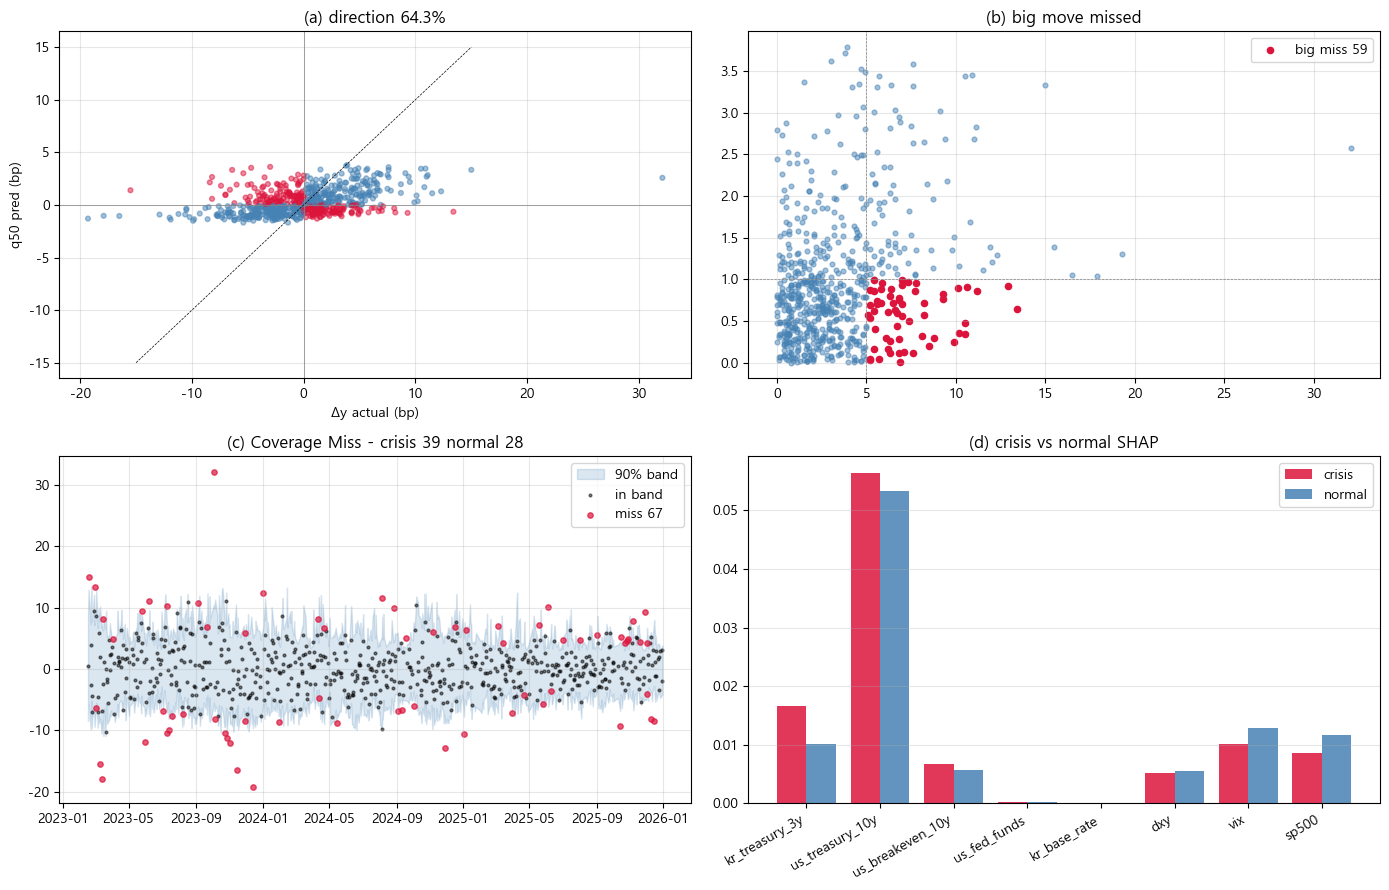

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ax = axes[0,0]
colors = df_test['sign_correct'].map({True:'steelblue', False:'crimson'})
ax.scatter(df_test['y_true_bp'], df_test['q50'], c=colors, alpha=0.5, s=12)
ax.axhline(0, color='gray', linewidth=0.5); ax.axvline(0, color='gray', linewidth=0.5)
ax.plot([-15,15],[-15,15], 'k--', linewidth=0.5)
ax.set_title('(a) direction ' + str(round(dir_acc*100,1)) + '%')
ax.set_xlabel('Δy actual (bp)'); ax.set_ylabel('q50 pred (bp)'); ax.grid(alpha=0.3)
ax = axes[0,1]
ax.scatter(df_test['y_true_bp'].abs(), df_test['q50'].abs(), alpha=0.5, s=12, color='steelblue')
ax.scatter(big_miss['y_true_bp'].abs(), big_miss['q50'].abs(), color='crimson', s=20, label='big miss '+str(len(big_miss)))
ax.axhline(1, color='gray', linewidth=0.5, linestyle='--'); ax.axvline(5, color='gray', linewidth=0.5, linestyle='--')
ax.set_title('(b) big move missed'); ax.legend(); ax.grid(alpha=0.3)
ax = axes[1,0]
ax.fill_between(df_test['date'], df_test['q05'], df_test['q95'], alpha=0.2, color='steelblue', label='90% band')
ax.scatter(df_test[df_test['in_band']]['date'], df_test[df_test['in_band']]['y_true_bp'], s=4, color='black', alpha=0.5, label='in band')
ax.scatter(df_test[~df_test['in_band']]['date'], df_test[~df_test['in_band']]['y_true_bp'], s=15, color='crimson', alpha=0.7, label='miss '+str(n_miss))
ax.set_title('(c) Coverage Miss - crisis ' + str(n_miss_crisis) + ' normal ' + str(n_miss_normal)); ax.legend(); ax.grid(alpha=0.3)
ax = axes[1,1]
if not diff_table.empty:
    x = np.arange(len(FROZEN))
    ax.bar(x-0.2, diff_table['shap_crisis'], width=0.4, color='crimson', alpha=0.85, label='crisis')
    ax.bar(x+0.2, diff_table['shap_normal'], width=0.4, color='steelblue', alpha=0.85, label='normal')
    ax.set_xticks(x); ax.set_xticklabels(diff_table['feature'], rotation=30, ha='right')
    ax.set_title('(d) crisis vs normal SHAP'); ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR/'w6_03_error_analysis_4axis.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. DM test (HAC + HLN + Bonferroni)

In [12]:
from scipy import stats as scistats
xgb_pred = pd.read_csv(DATA_DIR/'processed/xgb_predictions_w3.csv', parse_dates=['date'])
lstm_w4_pred = pd.read_csv(DATA_DIR/'processed/lstm_predictions_w4.csv', parse_dates=['date'])
a0_test = a0_pred_df[a0_pred_df['split']=='test'][['date','y_true_bp','q50']].rename(columns={'q50':'q50_a0'})
xgb_test = xgb_pred[xgb_pred['split']=='test'][['date','q50']].rename(columns={'q50':'q50_xgb'})
lstm_w4_test = lstm_w4_pred[lstm_w4_pred['split']=='test'][['date','q50']].rename(columns={'q50':'q50_lstm_raw'})
naive_test = a0_test.copy(); naive_test['q50_naive'] = 0.0
merged = a0_test.merge(xgb_test, on='date').merge(lstm_w4_test, on='date').merge(naive_test[['date','q50_naive']], on='date')
print('DM N =', len(merged))
def dm_test(e1, e2, h=1):
    e1 = np.asarray(e1); e2 = np.asarray(e2); d = e1**2 - e2**2
    T = len(d); d_mean = d.mean()
    L = max(1, int(np.floor(4*(T/100.0)**(2/9))))
    var_d = ((d - d_mean)**2).mean()
    for k in range(1, L+1):
        var_d += 2*(1-k/(L+1))*((d[:-k]-d_mean)*(d[k:]-d_mean)).mean()
    var_d = max(var_d, 1e-12)
    dm = d_mean / np.sqrt(var_d / T)
    correction = np.sqrt((T+1-2*h+h*(h-1)/T)/T)
    dm_hln = correction * dm
    p = 2 * (1 - scistats.t.cdf(abs(dm_hln), df=T-1))
    return float(dm), float(dm_hln), float(p), L, T
comparisons = [('A0_vs_Naive','q50_a0','q50_naive'),('A0_vs_XGBoost','q50_a0','q50_xgb'),('A0_vs_LSTM_raw','q50_a0','q50_lstm_raw')]
alpha = 0.05; m_test = len(comparisons); alpha_b = alpha/m_test
print('Bonferroni alpha* =', round(alpha_b, 4))
dm_rows = []
for name, c1, c2 in comparisons:
    e1 = (merged['y_true_bp'] - merged[c1]).values
    e2 = (merged['y_true_bp'] - merged[c2]).values
    dm, dm_hln, p, L, T = dm_test(e1, e2, h=1)
    rmse_1 = float(np.sqrt(np.mean(e1**2))); rmse_2 = float(np.sqrt(np.mean(e2**2)))
    sig_b = 'OK' if p < alpha_b else 'NS'
    direction = 'A0 wins' if dm_hln < 0 else 'other wins'
    dm_rows.append({'comparison':name,'T':T,'NW_lag':L,'rmse_a0':round(rmse_1,4),'rmse_other':round(rmse_2,4),
        'DM_raw':round(dm,3),'DM_HLN':round(dm_hln,3),'p_value':round(p,4),'bonf':sig_b,'direction':direction})
    print(' ', name, 'RMSE A0', round(rmse_1,3), 'vs', round(rmse_2,3), 'DM_HLN', round(dm_hln,3), 'p', round(p,4), sig_b)
dm_df = pd.DataFrame(dm_rows)
dm_df.to_csv(REPORT_DIR/'dm_test_w6.csv', index=False)
print('saved dm_test_w6.csv')

DM N = 672
Bonferroni alpha* = 0.0167
  A0_vs_Naive RMSE A0 4.17 vs 4.535 DM_HLN -6.805 p 0.0 OK
  A0_vs_XGBoost RMSE A0 4.17 vs 4.529 DM_HLN -6.963 p 0.0 OK
  A0_vs_LSTM_raw RMSE A0 4.17 vs 4.535 DM_HLN -6.714 p 0.0 OK
saved dm_test_w6.csv


## 6. 채널 부합 (V6 LOG #43: noise/weak/strong)

In [13]:
shap_signed_mean = shap_by_q[0.5].mean(axis=(0,1))
shap_abs_mean = np.abs(shap_by_q[0.5]).mean(axis=(0,1))
channel_hyp = {
    'kr_treasury_3y':   ('?', 'KR short-term yield curve'),
    'kr_base_rate':     ('+', 'monetary policy transmission'),
    'us_treasury_10y':  ('+', 'US-KR co-movement'),
    'us_fed_funds':     ('+', 'US monetary policy'),
    'us_breakeven_10y': ('+', 'inflation expectation'),
    'vix':              ('-', 'safe-haven demand'),
    'sp500':            ('-', 'risk-on/risk-off flow'),
    'dxy':              ('+', 'EM capital outflow'),
}
def signal_region(signed, abs_v):
    if abs_v == 0: return 'zero'
    ratio = abs(signed)/abs_v
    if ratio < 0.20: return 'noise'
    if ratio < 0.50: return 'weak'
    return 'strong'
channel_rows = []
for f in FROZEN:
    idx = FROZEN.index(f)
    s = float(shap_signed_mean[idx]); a = float(shap_abs_mean[idx])
    actual = '+' if s > 0 else ('-' if s < 0 else '0')
    hyp_sign, channel = channel_hyp[f]
    ratio = abs(s)/a if a else 0
    region = signal_region(s, a)
    if hyp_sign == '?': match = 'NA'
    elif region == 'noise': match = 'noise'
    else: match = ('OK' if actual == hyp_sign else 'NO')
    channel_rows.append({'feature':f,'hypothesis':hyp_sign,'actual_sign':actual,
        'shap_signed_mean':round(s,5),'shap_abs_mean':round(a,5),
        'signed_abs_ratio':round(ratio,3),'region':region,'match':match,'channel':channel})
    print(f, hyp_sign, actual, 'signed', round(s,5), '|SHAP|', round(a,5), 'ratio', round(ratio*100,1),'%', region, match)
channel_df = pd.DataFrame(channel_rows)
n_strong_match = int(((channel_df['match']=='OK') & (channel_df['region']=='strong')).sum())
n_strong_total = int((channel_df['region']=='strong').sum())
n_weak_match = int(((channel_df['match']=='OK') & (channel_df['region']=='weak')).sum())
n_weak_total = int((channel_df['region']=='weak').sum())
n_noise = int((channel_df['region']=='noise').sum())
print('strong match:', n_strong_match, '/', n_strong_total)
print('weak match:', n_weak_match, '/', n_weak_total)
print('noise:', n_noise, '(deferred)')
channel_df.to_csv(REPORT_DIR/'channel_validation_w6.csv', index=False)
print('saved channel_validation_w6.csv')

kr_treasury_3y ? - signed -0.00331 |SHAP| 0.01302 ratio 25.4 % weak NA
kr_base_rate + + signed 7e-05 |SHAP| 8e-05 ratio 85.9 % strong OK
us_treasury_10y + - signed -0.00656 |SHAP| 0.05467 ratio 12.0 % noise noise
us_fed_funds + + signed 8e-05 |SHAP| 0.00023 ratio 34.2 % weak OK
us_breakeven_10y + + signed 0.00095 |SHAP| 0.00612 ratio 15.5 % noise noise
vix - + signed 0.0017 |SHAP| 0.01166 ratio 14.6 % noise noise
sp500 - - signed -0.0001 |SHAP| 0.01031 ratio 1.0 % noise noise
dxy + - signed -0.00035 |SHAP| 0.00527 ratio 6.7 % noise noise
strong match: 1 / 1
weak match: 1 / 2
noise: 5 (deferred)
saved channel_validation_w6.csv


## 7. Summary

In [14]:
lines = []
lines.append('# W6 SHAP + Error Analysis + DM test Summary\n\n')
lines.append('## §1 Quantile SHAP top 3 (q50)\n')
for f, v in imp_table['q50'].sort_values(ascending=False).head(3).items():
    lines.append('- ' + f + ': ' + str(round(float(v),5)) + '\n')
lines.append('\n## §2 us_treasury_10y peak: t-' + str(peak_lag) + ' bdays, |SHAP|=' + str(round(float(us10y_time[peak_t]),5)) + '\n')
lines.append('\n## §3 Crisis (V3 train-only threshold = ' + str(round(float(vol_threshold),2)) + ' bp)\n')
lines.append('- crisis: ' + str(n_crisis) + '/' + str(len(test_dates)) + ' = ' + str(round(n_crisis/len(test_dates)*100,1)) + '%\n')
lines.append('\n## §4 Error analysis 4-axis\n')
lines.append('- (a) direction: ' + str(round(dir_acc*100,1)) + '%\n')
lines.append('- (b) big miss: ' + str(len(big_miss)) + ' (' + str(round(len(big_miss)/len(df_test)*100,1)) + '%)\n')
lines.append('- (c) Coverage: ' + str(round(df_test['in_band'].mean()*100,1)) + '%, crisis miss ' + str(round(rate_crisis*100,1)) + '% vs normal ' + str(round(rate_normal*100,1)) + '% (ratio ' + str(round(rate_crisis/rate_normal,2)) + 'x)\n')
if not diff_table.empty:
    top_d = diff_table.iloc[0]
    lines.append('- (d) crisis SHAP top diff: ' + str(top_d['feature']) + ' diff=' + str(round(float(top_d['diff_crisis_normal']),5)) + '\n')
lines.append('\n## §5 DM test (Bonferroni alpha* = ' + str(round(alpha_b,4)) + ')\n')
lines.append('| comparison | RMSE A0 | RMSE other | DM_HLN | p | Bonf |\n|---|---|---|---|---|---|\n')
for r in dm_rows:
    lines.append('| ' + r['comparison'] + ' | ' + str(r['rmse_a0']) + ' | ' + str(r['rmse_other']) + ' | ' + str(r['DM_HLN']) + ' | ' + str(r['p_value']) + ' | ' + r['bonf'] + ' |\n')
lines.append('\n## §6 Channel validation (V6 region split)\n')
lines.append('- strong region match: ' + str(n_strong_match) + '/' + str(n_strong_total) + '\n')
lines.append('- weak region match: ' + str(n_weak_match) + '/' + str(n_weak_total) + '\n')
lines.append('- noise region: ' + str(n_noise) + ' (deferred)\n\n')
for r in channel_rows:
    lines.append('- ' + r['feature'] + ' hyp ' + r['hypothesis'] + ' actual ' + r['actual_sign'] + ' (signed ' + str(r['shap_signed_mean']) + ', ratio ' + str(round(r['signed_abs_ratio']*100,1)) + '%) [' + r['region'] + '] ' + r['match'] + '\n')
(REPORT_DIR/'summary_w6.md').write_text(''.join(lines), encoding='utf-8')
print(''.join(lines))
print('saved summary_w6.md')

# W6 SHAP + Error Analysis + DM test Summary

## §1 Quantile SHAP top 3 (q50)
- us_treasury_10y: 0.05467
- kr_treasury_3y: 0.01302
- vix: 0.01166

## §2 us_treasury_10y peak: t-0 bdays, |SHAP|=1.09038

## §3 Crisis (V3 train-only threshold = 4.11 bp)
- crisis: 299/672 = 44.5%

## §4 Error analysis 4-axis
- (a) direction: 64.3%
- (b) big miss: 59 (8.8%)
- (c) Coverage: 90.0%, crisis miss 13.0% vs normal 7.5% (ratio 1.74x)
- (d) crisis SHAP top diff: kr_treasury_3y diff=0.00642

## §5 DM test (Bonferroni alpha* = 0.0167)
| comparison | RMSE A0 | RMSE other | DM_HLN | p | Bonf |
|---|---|---|---|---|---|
| A0_vs_Naive | 4.1699 | 4.5348 | -6.805 | 0.0 | OK |
| A0_vs_XGBoost | 4.1699 | 4.5287 | -6.963 | 0.0 | OK |
| A0_vs_LSTM_raw | 4.1699 | 4.5355 | -6.714 | 0.0 | OK |

## §6 Channel validation (V6 region split)
- strong region match: 1/1
- weak region match: 1/2
- noise region: 5 (deferred)

- kr_treasury_3y hyp ? actual - (signed -0.00331, ratio 25.4%) [weak] NA
- kr_base_rate hyp + actu